In [3]:
# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

np.random.seed(42)
tf.random.set_seed(42)


In [5]:
# 2. Load Dataset (Example: Kaggle Loan Dataset CSV)
data = pd.read_csv("credit_data.csv")   # apna dataset path daalna

In [6]:
# 3. Handle Missing Values
data = data.dropna()

In [7]:
# 4. Encode Categorical Variables
data = pd.get_dummies(data, drop_first=True)

In [11]:
# 5. Separate Features and Target
X = data.drop("credit_risk", axis=1)   # target column ka naam change karna
y = data["credit_risk"]

In [12]:
# 6. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [13]:
# 7. Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
# 8. Build MLP Model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

c:\Users\sharm\OneDrive\Desktop\Assignment 1 Deep Learning\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
# 9. Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [16]:
# 10. Train Model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32
)


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.5828 - loss: 0.6875 - val_accuracy: 0.6625 - val_loss: 0.6519
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6984 - loss: 0.6136 - val_accuracy: 0.6687 - val_loss: 0.6236
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7078 - loss: 0.5746 - val_accuracy: 0.6687 - val_loss: 0.6075
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7219 - loss: 0.5468 - val_accuracy: 0.6750 - val_loss: 0.5958
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7297 - loss: 0.5234 - val_accuracy: 0.6812 - val_loss: 0.5859
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7469 - loss: 0.5021 - val_accuracy: 0.6812 - val_loss: 0.5775
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7672 - loss: 0.4822 - val_accuracy: 0.7000 - val_loss: 0.5702
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7750 - loss: 0.4643 - val_accuracy: 0.7125 - v

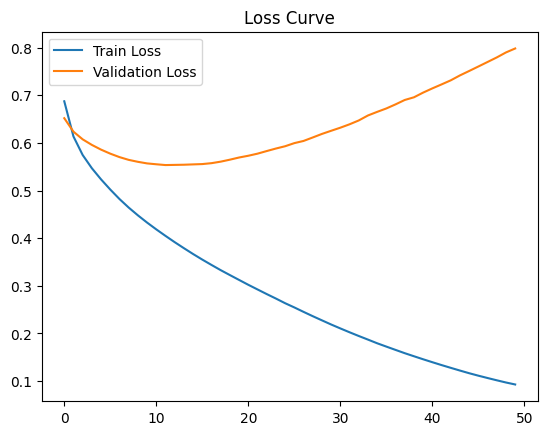

In [17]:
# 11. Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

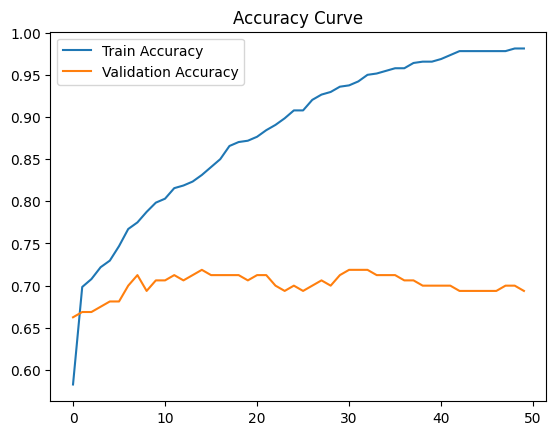

In [18]:
# 12. Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [19]:
# 13. Evaluation
y_pred = (model.predict(X_test) > 0.5).astype("int32")

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
[[ 32  27]
 [ 24 117]]
              precision    recall  f1-score   support

           0       0.57      0.54      0.56        59
           1       0.81      0.83      0.82       141

    accuracy                           0.74       200
   macro avg       0.69      0.69      0.69       200
weighted avg       0.74      0.74      0.74       200

